<a href="https://colab.research.google.com/github/paulsubarna/FedWeIT/blob/main/Pytorch_1_1_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.1 — PyTorch & Deep Learning Fundamentals

## Topics covered

| # | Section |
|---|---------|
| 1 | Tensor Fundamentals |
| 2 | Autograd & Computational Graphs |
| 3 | DataLoaders |
| 4 | Working with Image Data |
| 5 | Custom Dataset Classes |
| 6 | Data Transforms & Augmentation |
| 7 | Working with Text Data |
| 8 | GPU Support |
| 9 | Activation Functions |
| 10 | Loss Functions |
| 11 | `nn.Module` Internals |
| 12 | Weight Initialisation |
| 13 | Convolutional Neural Networks |
| 14 | Regularisation — Dropout & BatchNorm |
| 15 | Optimisers & Learning-Rate Schedulers |
| 16 | Train / Validation Split |
| 17 | Full Training Loop |
| 18 | Gradient Clipping |
| 19 | Model Saving & Loading |


In [1]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 72
matplotlib.rcParams["savefig.dpi"] = 72


## 1. Tensor Fundamentals

PyTorch tensors are **typed, strided, n-dimensional arrays** that optionally
carry a gradient history.  
### Memory layout & strides

Every tensor is backed by a **contiguous block of storage**.  The *stride* of
each dimension tells PyTorch how many elements to skip in memory to move one
step along that axis.

```
shape  = (B, H, W)
stride = (H*W, W, 1)   ← row-major (C-contiguous)
```

`transpose`, `permute`, and slicing return **views** — same storage, new
strides — so they are O(1) but the result may be non-contiguous.

### Einstein summation (`torch.einsum`)

`einsum` expresses any tensor contraction in one line of index notation:

| Operation | Einsum string |
|-----------|--------------|
| Matrix multiply | `"ij,jk->ik"` |
| Batched matmul | `"bij,bjk->bik"` |
| Outer product | `"i,j->ij"` |
| Trace | `"ii->"` |
| Scaled dot-product (attention) | `"bhi,bhj->bhij"` *(after unsqueeze)* |

### Advanced indexing & gather/scatter

PyTorch supports *integer-array indexing* (fancy indexing) and the
`torch.gather` / `torch.scatter` primitives used in, e.g., NLL loss and
memory-augmented networks.

**Exercises**
1. Verify strides before and after `transpose`; call `.contiguous()` and
   compare strides again.
2. Re-implement batched matrix multiply with `einsum`; confirm it matches `@`.
3. Use `torch.gather` to extract the predicted class score for each sample in a
   batch — this is exactly what `NLLLoss` does internally.
4. Benchmark `einsum` vs explicit loops on a 512-dim sequence of length 128.


Original strides : (48, 8, 1)
Transposed strides: (48, 1, 8)
Is contiguous?     False
After contiguous  : (48, 6, 1)

einsum == @? True
Trace via einsum: -1.043952226638794
Trace via .trace(): -1.043952226638794
Batched outer product shape: torch.Size([8, 16, 16])

Attention output shape: torch.Size([2, 10, 32])

Logit at true class (gather): tensor([-0.7415,  0.4578,  0.4024,  0.6276, -1.7879, -1.0770])
Matches manual loop? True


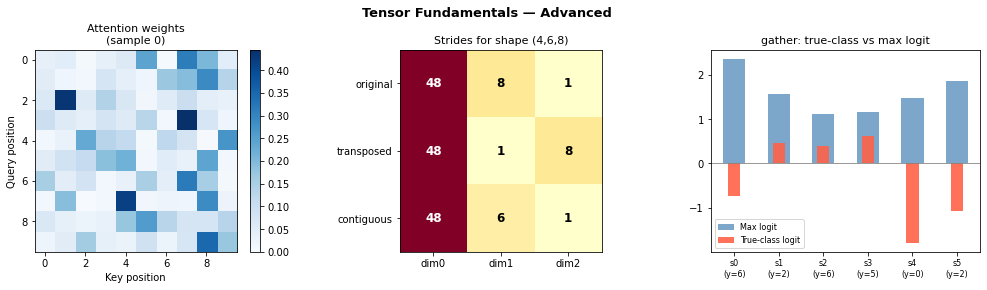

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# ── 1. Memory layout — shapes, strides, contiguity ────────────────────────────
x = torch.randn(4, 6, 8)          # shape (4, 6, 8), C-contiguous
print("Original strides :", x.stride())          # (48, 8, 1)

xt = x.transpose(1, 2)            # shape (4, 8, 6), non-contiguous view
print("Transposed strides:", xt.stride())         # (48, 1, 8)
print("Is contiguous?    ", xt.is_contiguous())   # False

xc = xt.contiguous()              # triggers a memory copy
print("After contiguous  :", xc.stride())         # (48, 6, 1)
print()


# ── 2. Einstein summation ──────────────────────────────────────────────────────
A = torch.randn(3, 4)
B = torch.randn(4, 5)

mm_at    = torch.einsum("ij,jk->ik", A, B)   # matrix multiply
mm_torch = A @ B
print("einsum == @?", torch.allclose(mm_at, mm_torch))

# Trace (sum of diagonal elements)
C = torch.randn(5, 5)
print("Trace via einsum:", torch.einsum("ii->", C).item())
print("Trace via .trace():", C.trace().item())

# Batched outer product → (B, i, j) tensor from two (B, i) and (B, j) tensors
B_size, d = 8, 16
u = torch.randn(B_size, d)
v = torch.randn(B_size, d)
outer = torch.einsum("bi,bj->bij", u, v)   # (8, 16, 16)
print(f"Batched outer product shape: {outer.shape}")
print()

# ── 3. Scaled dot-product attention (single head, manual) ─────────────────────
#   Q, K, V : (B, T, d_k)
B_size, T, d_k = 2, 10, 32
Q = torch.randn(B_size, T, d_k)
K = torch.randn(B_size, T, d_k)
V = torch.randn(B_size, T, d_k)

scores = torch.einsum("bqd,bkd->bqk", Q, K) / (d_k ** 0.5)  # (B, T, T)
weights = torch.softmax(scores, dim=-1)
out    = torch.einsum("bqk,bkd->bqd", weights, V)             # (B, T, d_k)
print(f"Attention output shape: {out.shape}")




# ── 4. Advanced indexing — torch.gather ───────────────────────────────────────
#   Simulate extracting the predicted-class logit for each sample.
batch, num_classes = 6, 10
logits = torch.randn(batch, num_classes)
labels = torch.randint(0, num_classes, (batch,))

# gather the score at the true class index (equivalent to NLLLoss indexing)
selected = torch.gather(logits, dim=1, index=labels.unsqueeze(1)).squeeze(1)
print("\nLogit at true class (gather):", selected)
# Equivalent loop for verification
manual = torch.stack([logits[i, labels[i]] for i in range(batch)])
print("Matches manual loop?", torch.allclose(selected, manual))

# ── 5. Visualisation ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Attention weight matrix (first sample)
im0 = axes[0].imshow(weights[0].detach().numpy(), cmap="Blues", vmin=0, vmax=weights[0].max().item())
axes[0].set_title("Attention weights\n(sample 0)", fontsize=11)
axes[0].set_xlabel("Key position"); axes[0].set_ylabel("Query position")
plt.colorbar(im0, ax=axes[0])

# Stride diagram
stride_data = np.array([[48, 8, 1],    # original
                         [48, 1, 8],    # transposed
                         [48, 6, 1]])   # contiguous copy
im1 = axes[1].imshow(stride_data, cmap="YlOrRd")
axes[1].set_xticks([0,1,2]); axes[1].set_xticklabels(["dim0","dim1","dim2"])
axes[1].set_yticks([0,1,2]); axes[1].set_yticklabels(["original","transposed","contiguous"])
axes[1].set_title("Strides for shape (4,6,8)", fontsize=11)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, stride_data[i,j], ha="center", va="center",
                     fontsize=12, fontweight="bold",
                     color="white" if stride_data[i,j] > 20 else "black")

# Gather: logits vs selected score
x_pos = np.arange(batch)
width = 0.5
bars = axes[2].bar(x_pos, logits.max(dim=1).values.detach().numpy(),
                   width, label="Max logit", color="steelblue", alpha=0.7)
axes[2].bar(x_pos, selected.detach().numpy(),
            width * 0.55, label="True-class logit", color="tomato", alpha=0.9)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f"s{i}\n(y={labels[i].item()})" for i in range(batch)], fontsize=8)
axes[2].set_title("gather: true-class vs max logit", fontsize=11)
axes[2].legend(fontsize=8)
axes[2].axhline(0, color="gray", linewidth=0.8)

plt.suptitle("Tensor Fundamentals — Advanced", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 2. Autograd & Computational Graphs

PyTorch builds a **dynamic computational graph** during the forward pass and
uses it to propagate gradients back via `loss.backward()`.

| Concept | Meaning |
|---|---|
| `requires_grad=True` | Track this tensor in the graph |
| `loss.backward()` | Compute all gradients |
| `tensor.grad` | Accumulated gradient (∂loss/∂tensor) |
| `torch.no_grad()` | Disable tracking (inference / plotting) |
| `grad.zero_()` | Reset gradient before next backward |

> **Common bug:** forgetting `zero_grad()` causes gradients to *accumulate*
> across iterations, silently corrupting training.

**Exercises**
1. Verify PyTorch's gradient against your hand-calculated value.
2. Run `backward()` twice without zeroing — what happens?


f(2)  = 17.0  (expected 17)
f'(2) = 14.0  (expected 14 = 6·2+2)

grad_fn inside no_grad: None

Accumulated grad (bug) : 6.0
Correct grad (zero_grad): 2.0


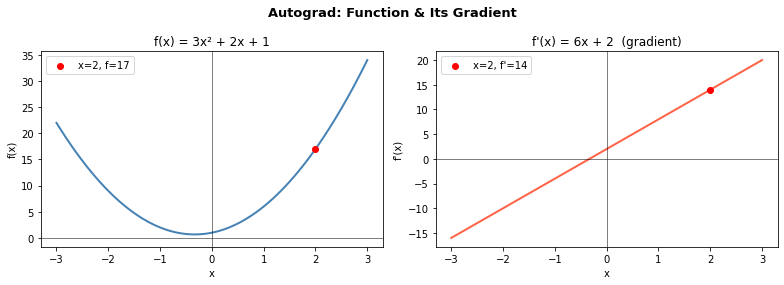

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ── Scalar gradient: f(x) = 3x² + 2x + 1  →  f'(x) = 6x + 2 ─────────────
x = torch.tensor(2.0, requires_grad=True)
y = 3 * x**2 + 2 * x + 1
y.backward()
print(f"f(2)  = {y.item():.1f}  (expected 17)")
print(f"f'(2) = {x.grad.item():.1f}  (expected 14 = 6·2+2)")

# ── torch.no_grad — no graph built ─────────────────────────────────────────
w = torch.randn(3, requires_grad=True)
inputs = torch.tensor([1.0, 2.0, 3.0])
with torch.no_grad():
    val = w * inputs
print("\ngrad_fn inside no_grad:", val.grad_fn)   # None

# ── Accumulation hazard vs. correct zero_grad pattern ──────────────────────
x_bad = torch.tensor(1.0, requires_grad=True)
for _ in range(3):
    (x_bad * 2).backward()
print(f"\nAccumulated grad (bug) : {x_bad.grad.item()}")   # 6.0

x_ok = torch.tensor(1.0, requires_grad=True)
for _ in range(3):
    if x_ok.grad is not None:
        x_ok.grad.zero_()
    (x_ok * 2).backward()
print(f"Correct grad (zero_grad): {x_ok.grad.item()}")      # 2.0

# ── Visualise f(x) and its gradient ────────────────────────────────────────
xs = torch.linspace(-3, 3, 100, requires_grad=False)
ys = 3 * xs**2 + 2 * xs + 1
grads = 6 * xs + 2                  # analytic derivative

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(xs.numpy(), ys.numpy(), color="steelblue", linewidth=2)
axes[0].set_title("f(x) = 3x² + 2x + 1")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].scatter([2], [17], color="red", zorder=5, label="x=2, f=17")
axes[0].legend()

axes[1].plot(xs.numpy(), grads.numpy(), color="tomato", linewidth=2)
axes[1].set_title("f'(x) = 6x + 2  (gradient)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f'(x)")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].scatter([2], [14], color="red", zorder=5, label="x=2, f'=14")
axes[1].legend()

plt.suptitle("Autograd: Function & Its Gradient", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 3. DataLoaders

`torch.utils.data.DataLoader` wraps a `Dataset` and provides:
- **Batching** — groups samples into mini-batches.
- **Shuffling** — randomises order each epoch.
- **Parallel loading** — `num_workers > 0` uses background processes.
- **Pinned memory** — `pin_memory=True` speeds CPU→GPU transfers.

**Exercises**
1. Create a `TensorDataset` and load it with a `DataLoader`.
2. Benchmark loading speed with `num_workers=0` vs `num_workers=2`.


Input  shape : torch.Size([64, 3])
Label  shape : torch.Size([64])
Output shape : torch.Size([64, 2])

num_workers=0 : 0.03s
num_workers=2 : 0.13s  (0.2x speed-up)


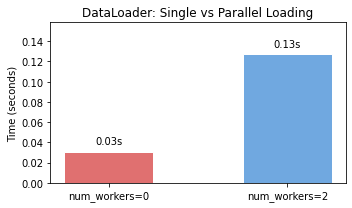

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt

X = torch.randn(10_000, 3)
y = torch.randint(0, 2, (10_000,))
dataset = TensorDataset(X, y)

# ── Inspect one batch ─────────────────────────────────────────────────────────
loader = DataLoader(dataset, batch_size=64, shuffle=True)
batch_X, batch_y = next(iter(loader))
out = nn.Linear(3, 2)(batch_X)
print(f"Input  shape : {batch_X.shape}")
print(f"Label  shape : {batch_y.shape}")
print(f"Output shape : {out.shape}")

# ── Benchmark: num_workers=0 vs 2 ─────────────────────────────────────────────
def time_loader(nw):
    ldr = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=nw)
    t0 = time.time()
    for _ in ldr:
        pass
    return time.time() - t0

t_single = time_loader(0)
t_multi  = time_loader(2)
print(f"\nnum_workers=0 : {t_single:.2f}s")
print(f"num_workers=2 : {t_multi:.2f}s  ({t_single/t_multi:.1f}x speed-up)")

# ── Visualise speed comparison ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["num_workers=0", "num_workers=2"], [t_single, t_multi],
              color=["#e07070", "#70a8e0"], edgecolor="white", width=0.5)
for bar, val in zip(bars, [t_single, t_multi]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.2f}s", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Time (seconds)")
ax.set_title("DataLoader: Single vs Parallel Loading")
ax.set_ylim(0, max(t_single, t_multi) * 1.25)
plt.tight_layout(); plt.show()


## 4. Working with Image Data

`torchvision.datasets` provides ready-to-use benchmark datasets such as
CIFAR-10, MNIST, Imagenette, and more. Each dataset returns `(image, label)`
pairs and accepts a `transform` pipeline.

**Exercises**
1. Load CIFAR-10 and display a grid of sample images with their class names.
2. Inspect the tensor shape — what do the three dimensions represent?


100%|██████████| 170M/170M [00:22<00:00, 7.47MB/s] 


Batch shape : torch.Size([64, 3, 32, 32])  — (N, C, H, W)
Label shape : torch.Size([64])
Pixel range : [-1.99, 2.13]  (normalised)


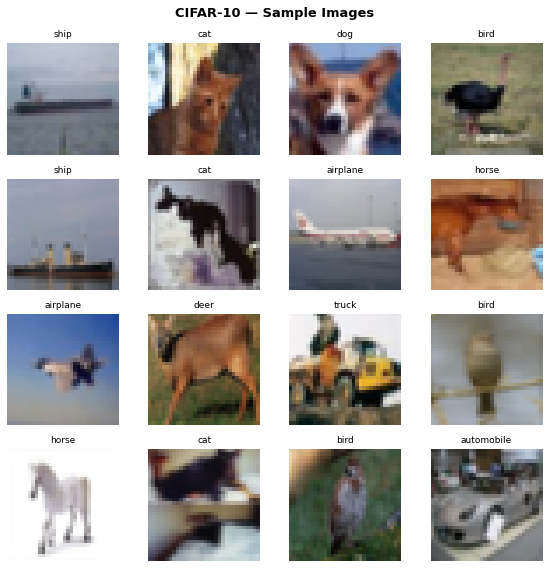

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

train_data   = datasets.CIFAR10(root="data", train=True,  download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)

images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}  — (N, C, H, W)")
print(f"Label shape : {labels.shape}")
print(f"Pixel range : [{images.min():.2f}, {images.max():.2f}]  (normalised)")

# ── Display 4×4 grid with class names ────────────────────────────────────────
def denorm(t):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flatten()):
    img = denorm(images[idx]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[labels[idx].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("CIFAR-10 — Sample Images", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 5. Custom Dataset Classes

When a dataset doesn't match a built-in format you subclass
`torch.utils.data.Dataset` and implement two methods:

| Method | Responsibility |
|---|---|
| `__len__` | Return the total number of samples |
| `__getitem__(i)` | Load and return the i-th sample |

Loading is *lazy* — files are opened only when `__getitem__` is called, so
the entire dataset never has to fit in RAM at once.


In [6]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

# Download Imagenette (a 10-class subset of ImageNet)
train_data = datasets.Imagenette(root="data", split="train", download=True, transform=None)

class ImageFolderDataset(Dataset):
    """Generic image-folder dataset.
    Expects:  root/class_name/img.JPEG  (or .jpg / .png)
    """
    EXTENSIONS = {".jpeg", ".jpg", ".png", ".JPEG"}

    def __init__(self, image_directory, transform=None):
        super().__init__()
        self.transform = transform
        self.images, self.labels = [], []
        self.class_to_idx = {}

        class_names = sorted(os.listdir(image_directory))
        for idx, cls in enumerate(class_names):
            self.class_to_idx[cls] = idx
            cls_dir = os.path.join(image_directory, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if os.path.splitext(fname)[1] in self.EXTENSIONS:
                    self.images.append(os.path.join(cls_dir, fname))
                    self.labels.append(idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Demonstrate size-mismatch error without a resize transform
raw_ds = ImageFolderDataset("data/imagenette2/train", transform=transforms.ToTensor())
raw_loader = DataLoader(raw_ds, batch_size=8, shuffle=True)
try:
    imgs, lbls = next(iter(raw_loader))
except RuntimeError as e:
    print("Expected error:", str(e)[:90], "...")
print(f"Dataset size: {len(raw_ds):,} images across {len(raw_ds.class_to_idx)} classes")


100%|██████████| 1.56G/1.56G [00:53<00:00, 29.2MB/s]


Expected error: stack expects each tensor to be equal size, but got [3, 593, 991] at entry 0 and [3, 376,  ...
Dataset size: 9,469 images across 10 classes


## 6. Data Transforms & Augmentation

`transforms.Compose` chains multiple transforms into a single callable.

**Why augment?**
- **RandomHorizontalFlip** — the network sees mirrored versions; a ship is
  still a ship even flipped.
- **RandomResizedCrop** — invariance to scale and position.
- **ColorJitter** — robustness to lighting changes.
- **Normalize** — zero-centred, unit-variance inputs stabilise training.

Augmentation artificially increases dataset diversity, reducing overfitting
without collecting more data.


Batch shape after transform: torch.Size([8, 3, 224, 224])


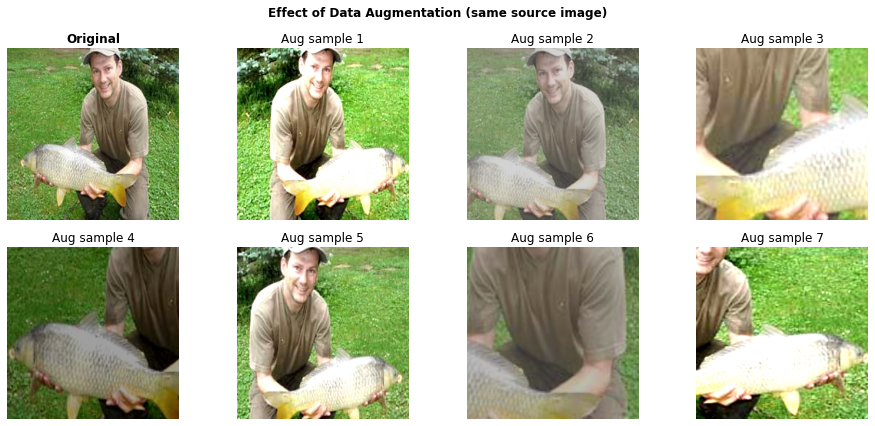

In [7]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Re-use the custom dataset from section 5
fix_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

imagenette = ImageFolderDataset("data/imagenette2/train", transform=fix_transform)
from torch.utils.data import DataLoader
loader = DataLoader(imagenette, batch_size=8, shuffle=True, num_workers=2)
images, labels = next(iter(loader))
print(f"Batch shape after transform: {images.shape}")   # (8, 3, 224, 224)

# ── Show 1 image with 6 different augmentation samples ────────────────────────
raw_img = Image.open(imagenette.images[0]).convert("RGB")
aug_only = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
])

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
axes[0, 0].imshow(raw_img.resize((224, 224)))
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")
for i, ax in enumerate(axes.flatten()[1:]):
    ax.imshow(aug_only(raw_img))
    ax.set_title(f"Aug sample {i+1}")
    ax.axis("off")
plt.suptitle("Effect of Data Augmentation (same source image)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 7. Working with Text Data

Unlike images, text must be converted to numbers before it can enter a model.
The standard pipeline is:

```
raw text  →  tokenise  →  token IDs  →  attention mask  →  model
```

We use a pre-trained BERT tokeniser from Hugging Face, which handles
vocabulary lookup, padding, and truncation automatically.


In [8]:
# Create tiny sentiment dataset files
sample_train = (
    "This movie was absolutely fantastic!\tpositive\n"
    "I really enjoyed the storyline and acting.\tpositive\n"
    "A total waste of time, very disappointing.\tnegative\n"
    "Brilliant performances from the entire cast.\tpositive\n"
    "Boring plot and terrible special effects.\tnegative\n"
)
sample_val = (
    "An unforgettable cinematic experience.\tpositive\n"
    "Could not sit through the second half.\tnegative\n"
)
with open("train.txt", "w") as f: f.write(sample_train)
with open("val.txt",   "w") as f: f.write(sample_val)
print("Text files created.")


Text files created.


/home/spaul/project/uv_ivon/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenised batch keys and shapes:
  input_ids           : torch.Size([4, 64])
  token_type_ids      : torch.Size([4, 64])
  attention_mask      : torch.Size([4, 64])
  labels              : torch.Size([4])


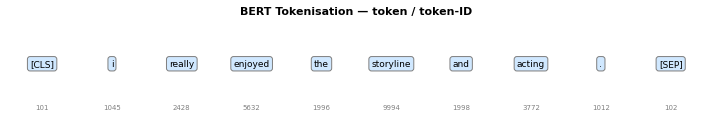

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
label2idx = {"negative": 0, "positive": 1}

class TextDataset(Dataset):
    def __init__(self, file_path, tokenizer, label2idx, max_length=64):
        self.tokenizer  = tokenizer
        self.label2idx  = label2idx
        self.max_length = max_length
        self.samples    = []
        with open(file_path, encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) == 2:
                    self.samples.append(parts)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        text, label = self.samples[idx]
        enc = self.tokenizer(text, padding="max_length", truncation=True,
                             max_length=self.max_length, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.label2idx[label], dtype=torch.long)
        return item

train_ds = TextDataset("train.txt", tokenizer, label2idx)
val_ds   = TextDataset("val.txt",   tokenizer, label2idx)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)

batch = next(iter(train_loader))
print("Tokenised batch keys and shapes:")
for k, v in batch.items():
    print(f"  {k:20s}: {v.shape}")

# ── Visualise token IDs for one sample ───────────────────────────────────────
ids     = batch["input_ids"][0].tolist()
tokens  = tokenizer.convert_ids_to_tokens(ids)
nonpad  = [(t, i) for t, i in zip(tokens, ids) if t != "[PAD]"]

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis("off")
for col, (tok, tid) in enumerate(nonpad):
    ax.text(col, 0.6, tok,  ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#d0e8ff", edgecolor="grey"))
    ax.text(col, 0.2, str(tid), ha="center", va="center", fontsize=7, color="grey")
ax.set_xlim(-0.5, len(nonpad) - 0.5)
ax.set_ylim(0, 1)
plt.title("BERT Tokenisation — token / token-ID", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


## 8. GPU Support

Placing tensors and models on a GPU can give **10–100×** speed-ups for large
matrix operations.  Always write device-agnostic code:

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)
data   = data.to(device)   # inside the training loop, per batch
```

**Rules of thumb**
- Model *and* data must be on the **same** device.
- Move tensors back with `.detach().cpu()` before NumPy / Matplotlib calls.
- `pin_memory=True` in the DataLoader speeds up CPU→GPU transfers.


Active device: cuda
GPU name     : NVIDIA RTX 6000 Ada Generation
VRAM total   : 50.87 GB

Result device  : cuda:0
Result shape   : torch.Size([512, 512])


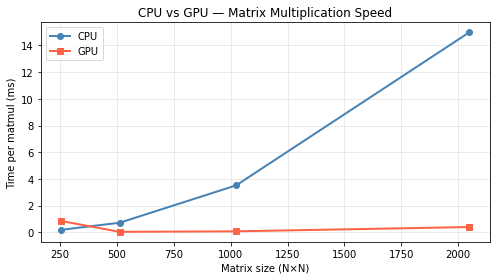

In [10]:
import torch
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Active device:", device)
if device.type == "cuda":
    print("GPU name     :", torch.cuda.get_device_name(0))
    print("VRAM total   :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

# ── Device transfer demo ──────────────────────────────────────────────────────
x = torch.randn(512, 512)
x_dev = x.to(device)
z     = (x_dev @ x_dev.T)
print(f"\nResult device  : {z.device}")
print(f"Result shape   : {z.shape}")

# ── Speed benchmark: matrix multiply on CPU vs GPU (if available) ─────────────
sizes  = [256, 512, 1024, 2048]
t_cpu, t_gpu = [], []

for s in sizes:
    A = torch.randn(s, s)
    t0 = time.time()
    for _ in range(10): _ = A @ A
    t_cpu.append((time.time() - t0) / 10 * 1000)

    if device.type == "cuda":
        A_g = A.to(device)
        torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(10): _ = A_g @ A_g
        torch.cuda.synchronize()
        t_gpu.append((time.time() - t0) / 10 * 1000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, t_cpu, "o-", label="CPU", color="steelblue", linewidth=2)
if t_gpu:
    ax.plot(sizes, t_gpu, "s-", label="GPU", color="tomato", linewidth=2)
ax.set_xlabel("Matrix size (N×N)"); ax.set_ylabel("Time per matmul (ms)")
ax.set_title("CPU vs GPU — Matrix Multiplication Speed")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Activation Functions

Activation functions introduce **non-linearity**, enabling networks to learn
complex mappings.

| Function | When to use |
|---|---|
| **Sigmoid** | Binary output, gating (LSTM) |
| **Tanh** | RNNs — zero-centred version of sigmoid |
| **ReLU** | Default choice for hidden layers |
| **LeakyReLU** | Avoids dead neurons in deep nets |
| **GELU** | Transformers (BERT, GPT, ViT) |

**Vanishing gradients:** Sigmoid/Tanh saturate for large |x|, giving near-zero
gradients.  Deep stacks of these layers make training very slow or impossible.
ReLU avoids this in positive regions.


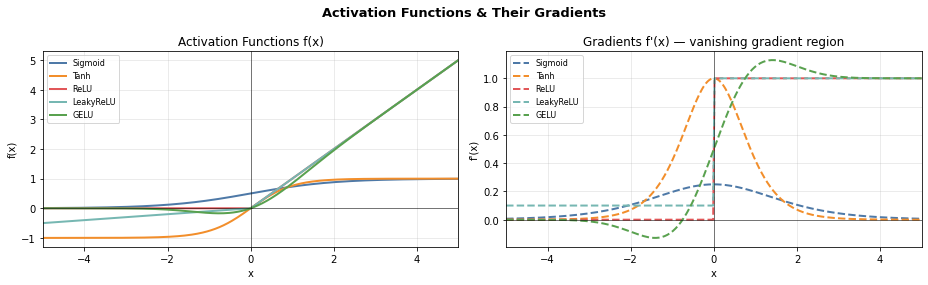

In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 300)

activations = {
    "Sigmoid":   torch.sigmoid(x),
    "Tanh":      torch.tanh(x),
    "ReLU":      F.relu(x),
    "LeakyReLU": F.leaky_relu(x, negative_slope=0.1),
    "GELU":      F.gelu(x),
}

# Compute gradients
grads = {}
for name, _ in activations.items():
    xi = x.clone().detach().requires_grad_(True)
    fn = {"Sigmoid": torch.sigmoid, "Tanh": torch.tanh,
          "ReLU": F.relu, "LeakyReLU": lambda t: F.leaky_relu(t, 0.1),
          "GELU": F.gelu}[name]
    fn(xi).sum().backward()
    grads[name] = xi.grad.detach()

colors = ["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (name, vals), color in zip(activations.items(), colors):
    axes[0].plot(x.numpy(), vals.numpy(), label=name, color=color, linewidth=2)
    axes[1].plot(x.numpy(), grads[name].numpy(), label=name, color=color,
                 linewidth=2, linestyle="--")

for ax, title, ylabel in zip(axes,
        ["Activation Functions f(x)", "Gradients f'(x) — vanishing gradient region"],
        ["f(x)", "f'(x)"]):
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("x"); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

plt.suptitle("Activation Functions & Their Gradients", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 10. Loss Functions

The loss function measures how wrong the model is.  Choosing the right one
depends on the task:

| Task | Loss | Notes |
|---|---|---|
| Multi-class classification | `CrossEntropyLoss` | Logits in, softmax internal |
| Binary classification | `BCEWithLogitsLoss` | Numerically stable |
| Regression | `MSELoss` | Penalises large errors heavily |
| Regression (robust) | `L1Loss` | Linear penalty — ignores outliers |
| Regression (balanced) | `HuberLoss` | MSE near 0, L1 for large errors |

**MSE vs L1:** MSE squares each residual so large errors dominate; L1 is
linear so outliers have less influence.


CrossEntropyLoss   : 2.4179
BCEWithLogitsLoss  : 0.5375
MSELoss            : 5.1411
L1Loss             : 0.6763
HuberLoss          : 0.7117


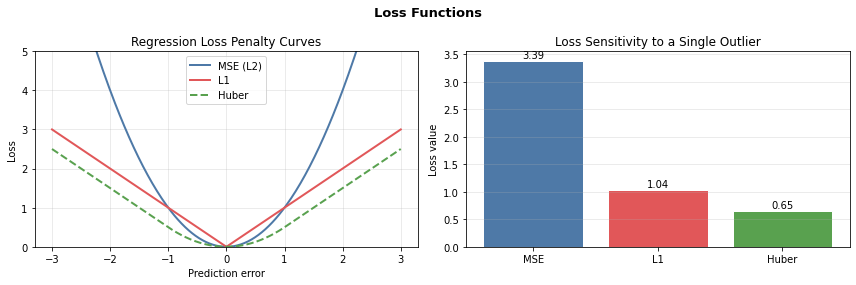

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# ── Compute losses on random data ─────────────────────────────────────────────
ce  = nn.CrossEntropyLoss()(torch.randn(8, 10), torch.randint(0, 10, (8,)))
bce = nn.BCEWithLogitsLoss()(torch.randn(8, 1), torch.randint(0, 2, (8, 1)).float())
mse = nn.MSELoss()(torch.randn(8), torch.randn(8))
l1  = nn.L1Loss()(torch.randn(8), torch.randn(8))
hub = nn.HuberLoss()(torch.randn(8), torch.randn(8))

print(f"CrossEntropyLoss   : {ce.item():.4f}")
print(f"BCEWithLogitsLoss  : {bce.item():.4f}")
print(f"MSELoss            : {mse.item():.4f}")
print(f"L1Loss             : {l1.item():.4f}")
print(f"HuberLoss          : {hub.item():.4f}")

# ── Visualise penalty curves ───────────────────────────────────────────────────
errors = torch.linspace(-3, 3, 300)
penalty_mse   = errors ** 2
penalty_l1    = errors.abs()
penalty_huber = torch.where(errors.abs() <= 1,
                            0.5 * errors**2,
                            errors.abs() - 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Penalty curves
axes[0].plot(errors, penalty_mse,   label="MSE (L2)",   linewidth=2, color="#4e79a7")
axes[0].plot(errors, penalty_l1,    label="L1",         linewidth=2, color="#e15759")
axes[0].plot(errors, penalty_huber, label="Huber",      linewidth=2, color="#59a14f",
             linestyle="--")
axes[0].set_title("Regression Loss Penalty Curves")
axes[0].set_xlabel("Prediction error"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 5)

# Effect of an outlier
preds = torch.randn(30)
truth = torch.zeros(30)
truth[0] = 10.0  # outlier

mse_val   = (preds - truth).pow(2).mean()
l1_val    = (preds - truth).abs().mean()
huber_val = nn.HuberLoss()(preds, truth)
axes[1].bar(["MSE", "L1", "Huber"],
            [mse_val.item(), l1_val.item(), huber_val.item()],
            color=["#4e79a7","#e15759","#59a14f"], edgecolor="white")
axes[1].set_title("Loss Sensitivity to a Single Outlier")
axes[1].set_ylabel("Loss value"); axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate([mse_val, l1_val, huber_val]):
    axes[1].text(i, v.item() + 0.05, f"{v.item():.2f}", ha="center", fontsize=10)

plt.suptitle("Loss Functions", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 11. `nn.Module` Internals

Every PyTorch model subclasses `nn.Module`.  Key utilities:

| Call | What it gives you |
|---|---|
| `model.parameters()` | All learnable tensors |
| `model.named_parameters()` | Name + tensor pairs |
| `param.requires_grad = False` | Freeze a layer |
| `model.train()` / `model.eval()` | Toggle Dropout & BatchNorm behaviour |

Freezing layers is the cornerstone of **transfer learning** — keep a
pre-trained backbone fixed and only train the new head.


fc1.weight            [256, 784]          params=200,704
fc1.bias              [256]               params=256
fc2.weight            [128, 256]          params=32,768
fc2.bias              [128]               params=128
fc3.weight            [10, 128]           params=1,280
fc3.bias              [10]                params=10

Total     : 235,146
Trainable : 235,146
Trainable after freezing fc1: 34,186


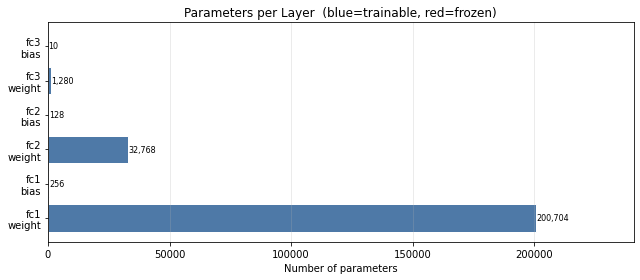

In [13]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        return self.fc3(torch.relu(self.fc2(torch.relu(self.fc1(x)))))

model = SimpleNet()

# ── Parameter summary ─────────────────────────────────────────────────────────
layer_info = []
for name, param in model.named_parameters():
    layer_info.append((name, param.numel(), param.requires_grad))
    print(f"{name:20s}  {str(list(param.shape)):18s}  params={param.numel():,}")

total     = sum(n for _, n, _ in layer_info)
trainable = sum(n for _, n, req in layer_info if req)
print(f"\nTotal     : {total:,}")
print(f"Trainable : {trainable:,}")

# ── Freeze fc1 ────────────────────────────────────────────────────────────────
for p in model.fc1.parameters():
    p.requires_grad = False
trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable after freezing fc1: {trainable_after:,}")

# ── Visualise parameter distribution per layer ────────────────────────────────
names  = [n.replace(".weight","\nweight").replace(".bias","\nbias")
          for n, _, _ in layer_info]
counts = [n for _, n, _ in layer_info]
colors = ["#4e79a7" if req else "#e15759" for _, _, req in layer_info]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, counts, color=colors, edgecolor="white")
ax.set_xlabel("Number of parameters")
ax.set_title("Parameters per Layer  (blue=trainable, red=frozen)")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{cnt:,}", va="center", fontsize=8)
ax.set_xlim(0, max(counts) * 1.2)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


## 12. Weight Initialisation

Poor initialisation can cause:
- **Vanishing gradients** — weights too small → gradients shrink to zero.
- **Exploding gradients** — weights too large → gradients blow up.
- **Symmetry** — all-zero init means every neuron learns identically.

| Method | Best for |
|---|---|
| **Xavier / Glorot** | Sigmoid / Tanh activations |
| **Kaiming / He** | ReLU family |
| **Orthogonal** | RNNs |
| **Uniform** | Baseline comparison |


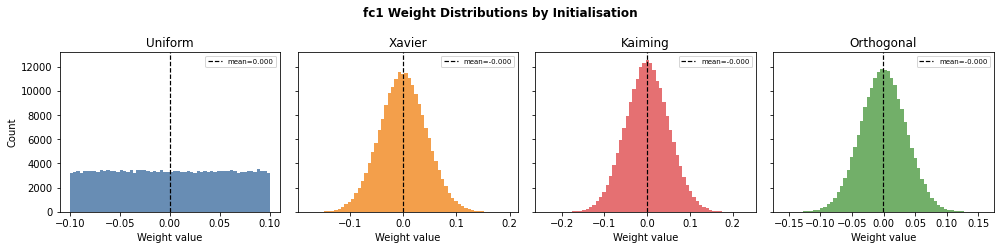

Uniform       output variance = 0.2793
Xavier        output variance = 0.6586
Kaiming       output variance = 2.0431
Orthogonal    output variance = 0.2406


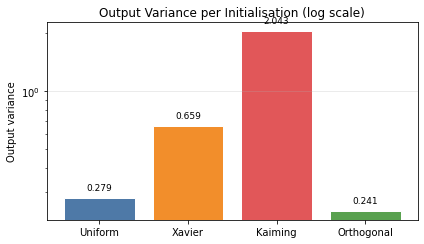

In [14]:
import torch, torch.nn as nn, torch.nn.init as init
import matplotlib.pyplot as plt

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
    def forward(self, x):
        return self.fc3(torch.relu(self.fc2(torch.relu(self.fc1(x)))))

def init_xavier(m):
    if isinstance(m, nn.Linear):
        init.xavier_normal_(m.weight); init.zeros_(m.bias)

def init_uniform(m):
    if isinstance(m, nn.Linear):
        init.uniform_(m.weight, -0.1, 0.1); init.zeros_(m.bias)

def init_kaiming(m):
    if isinstance(m, nn.Linear):
        init.kaiming_normal_(m.weight, nonlinearity="relu"); init.zeros_(m.bias)

def init_orthogonal(m):
    if isinstance(m, nn.Linear):
        init.orthogonal_(m.weight); init.zeros_(m.bias)

inits = {
    "Uniform":    init_uniform,
    "Xavier":     init_xavier,
    "Kaiming":    init_kaiming,
    "Orthogonal": init_orthogonal,
}
colors = ["#4e79a7","#f28e2b","#e15759","#59a14f"]

# ── Weight distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
for ax, (name, fn), color in zip(axes, inits.items(), colors):
    m = SimpleNet(); m.apply(fn)
    w = m.fc1.weight.data.view(-1).numpy()
    ax.hist(w, bins=60, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(name); ax.set_xlabel("Weight value")
    ax.axvline(w.mean(), color="black", linewidth=1.2, linestyle="--",
               label=f"mean={w.mean():.3f}")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Count")
plt.suptitle("fc1 Weight Distributions by Initialisation", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Output variance ───────────────────────────────────────────────────────────
x_test = torch.randn(100, 784)
vars_ = []
for name, fn in inits.items():
    m = SimpleNet(); m.apply(fn)
    with torch.no_grad():
        var = m(x_test).var().item()
    vars_.append(var)
    print(f"{name:12s}  output variance = {var:.4f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(list(inits.keys()), vars_, color=colors, edgecolor="white")
ax.set_ylabel("Output variance"); ax.set_yscale("log")
ax.set_title("Output Variance per Initialisation (log scale)")
for bar, v in zip(bars, vars_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
            f"{v:.3f}", ha="center", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 13. Convolutional Neural Networks (CNNs)

Convolutions exploit the spatial structure of images through:
- **Parameter sharing** — the same filter scans every location.
- **Local connectivity** — each output depends only on a neighbourhood.
- **Translation equivariance** — a feature detected anywhere activates the map.

**Spatial size formula** (per dimension):

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1$$

where *p* = padding, *k* = kernel size, *s* = stride.


SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 1,070,986

Input       : torch.Size([4, 3, 32, 32])
After block1: torch.Size([4, 32, 16, 16])
After block2: torch.Size([4, 64, 8, 8]

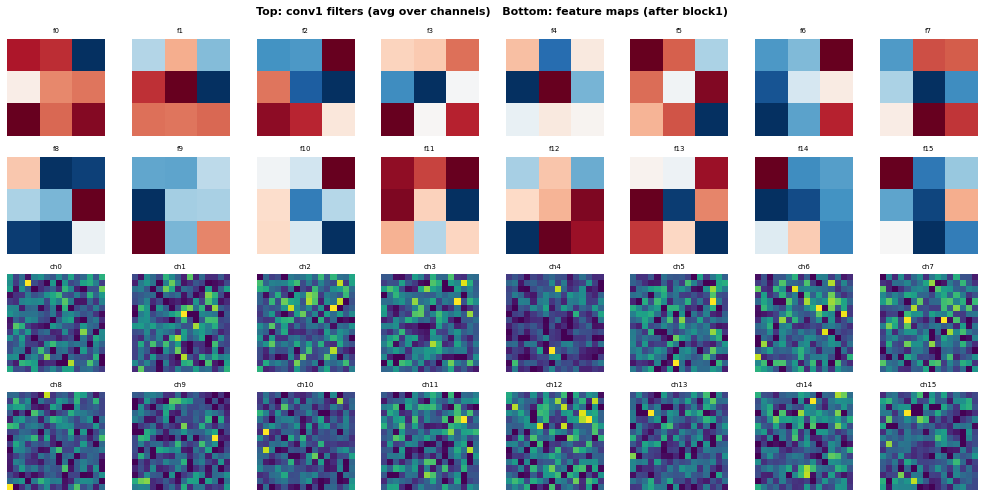

In [15]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt

class SimpleCNN(nn.Module):
    """Two conv blocks followed by a classifier head."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))  # 32→16
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))  # 16→8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.block2(self.block1(x)))

model = SimpleCNN()
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")

# ── Verify shapes through the network ────────────────────────────────────────
x = torch.randn(4, 3, 32, 32)
with torch.no_grad():
    after_b1 = model.block1(x)
    after_b2 = model.block2(after_b1)
    out      = model.classifier(after_b2)
print(f"\nInput       : {x.shape}")
print(f"After block1: {after_b1.shape}")
print(f"After block2: {after_b2.shape}")
print(f"Output      : {out.shape}")

# ── Visualise learned filters & one feature map ───────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(14, 7))

# First 32 filters of conv1 (3-channel → average for display)
for i, ax in enumerate(axes[:2].flatten()):
    filt = model.block1[0].weight.data[i].mean(0).numpy()
    ax.imshow(filt, cmap="RdBu_r"); ax.axis("off")
    ax.set_title(f"f{i}", fontsize=7)

# Feature maps produced by a dummy input
dummy = torch.randn(1, 3, 32, 32)
with torch.no_grad():
    fmaps = model.block1(dummy)[0]   # (32, 16, 16)
for i, ax in enumerate(axes[2:].flatten()):
    ax.imshow(fmaps[i].numpy(), cmap="viridis"); ax.axis("off")
    ax.set_title(f"ch{i}", fontsize=7)

plt.suptitle("Top: conv1 filters (avg over channels)   "
             "Bottom: feature maps (after block1)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


## 14. Regularisation — Dropout, Batch Norm & Layer Norm

| Technique | Mechanism | Key parameter |
|---|---|---|
| **Dropout** | Zero random activations at train time | `p` (drop probability) |
| **BatchNorm** | Normalise across the **batch** dimension, per feature | learnable γ, β |
| **LayerNorm** | Normalise across the **feature** dimension, per sample | learnable γ, β |
| **L2 / weight decay** | Penalise large weights in the optimiser | `weight_decay` |

### BatchNorm vs LayerNorm — when to use which?

|  | `nn.BatchNorm1d/2d` | `nn.LayerNorm` |
|---|---|---|
| **Normalises over** | Batch axis (N) | Feature axis (C / hidden) |
| **Depends on batch size** | Yes — unstable for small batches | No — works for batch=1 |
| **train vs eval** | Different (running stats in eval) | Same |
| **Typical use** | CNNs, vision models | Transformers, RNNs, NLP |

**Important:** always call `model.eval()` before inference — it disables
Dropout and switches BatchNorm to its running statistics.


TRAIN mode — mean |diff| : 0.5543  (Dropout active)
EVAL  mode — mean |diff| : 0.000000  (Dropout off)


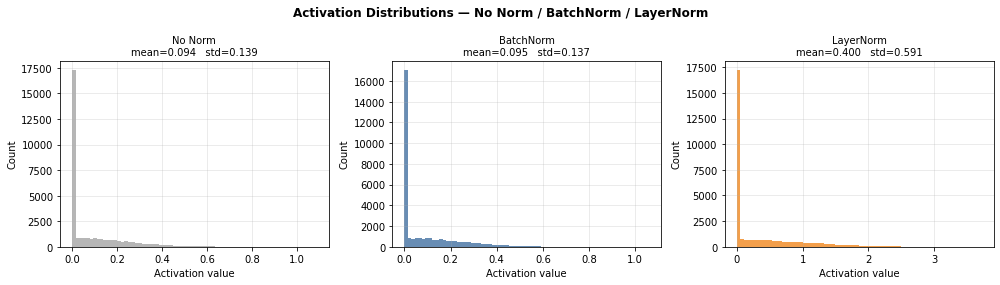

In [16]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
x = torch.randn(256, 784)   # (batch=256, features=784)

# ── Dropout: train vs eval difference ────────────────────────────────────────
class RegNet(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

model = RegNet(p=0.5)
model.train()
y1, y2 = model(x), model(x)
print(f"TRAIN mode — mean |diff| : {(y1-y2).abs().mean():.4f}  (Dropout active)")
model.eval()
with torch.no_grad():
    y3, y4 = model(x), model(x)
print(f"EVAL  mode — mean |diff| : {(y3-y4).abs().mean():.6f}  (Dropout off)")

# ── Three networks: no norm / BatchNorm / LayerNorm ──────────────────────────
class NoNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(784, 256)
        self.l2 = nn.Linear(256, 128)
    def forward(self, x):
        return torch.relu(self.l2(torch.relu(self.l1(x))))

class WithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.l2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
    def forward(self, x):
        return torch.relu(self.bn2(self.l2(torch.relu(self.bn1(self.l1(x))))))

class WithLN(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(784, 256)
        self.ln1 = nn.LayerNorm(256)
        self.l2 = nn.Linear(256, 128)
        self.ln2 = nn.LayerNorm(128)
    def forward(self, x):
        return torch.relu(self.ln2(self.l2(torch.relu(self.ln1(self.l1(x))))))

no_norm = NoNorm().eval()
bn_net  = WithBN().eval()
ln_net  = WithLN().eval()

with torch.no_grad():
    act_none = no_norm(x).numpy().ravel()
    act_bn   = bn_net(x).numpy().ravel()
    act_ln   = ln_net(x).numpy().ravel()

# ── Plot activation distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, act, title, color in zip(
        axes,
        [act_none, act_bn,  act_ln],
        ["No Norm", "BatchNorm", "LayerNorm"],
        ["#aaaaaa", "#4e79a7", "#f28e2b"]):
    ax.hist(act, bins=70, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(f"{title}\nmean={act.mean():.3f}   std={act.std():.3f}",
                 fontsize=10)
    ax.set_xlabel("Activation value"); ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

plt.suptitle("Activation Distributions — No Norm / BatchNorm / LayerNorm",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


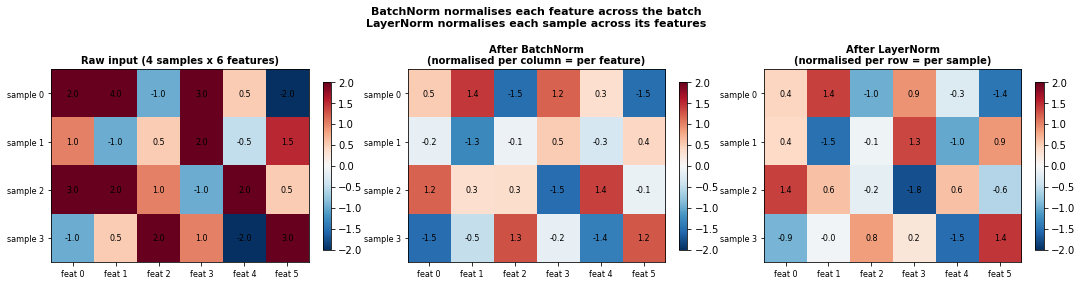

/tmp/ipykernel_2688234/1559829002.py:72: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  ln_stds.append(out_ln.mean(dim=1).std().item())


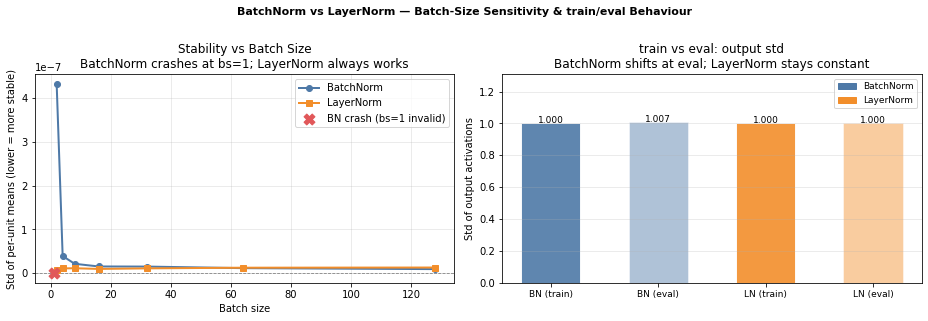

In [17]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# ── How normalisation axes differ ─────────────────────────────────────────────
# Input shape: (N=4 samples, D=6 features)
x_small = torch.tensor([
    [2.0,  4.0, -1.0,  3.0,  0.5, -2.0],
    [1.0, -1.0,  0.5,  2.0, -0.5,  1.5],
    [3.0,  2.0,  1.0, -1.0,  2.0,  0.5],
    [-1.0, 0.5,  2.0,  1.0, -2.0,  3.0],
])   # (4, 6)

bn = nn.BatchNorm1d(6, affine=False)
ln = nn.LayerNorm(6,   elementwise_affine=False)

bn.train()
x_bn = bn(x_small).detach().numpy()
x_ln = ln(x_small).detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def draw_matrix(ax, data, title, row_labels, col_labels, cmap):
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=-2, vmax=2)
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, fontsize=8)
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.1f}", ha="center", va="center",
                    fontsize=8, color="black")
    ax.set_title(title, fontsize=10, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.03)

rows = [f"sample {i}" for i in range(4)]
cols = [f"feat {j}" for j in range(6)]

draw_matrix(axes[0], x_small.numpy(), "Raw input (4 samples x 6 features)", rows, cols, "RdBu_r")
draw_matrix(axes[1], x_bn,            "After BatchNorm\n(normalised per column = per feature)", rows, cols, "RdBu_r")
draw_matrix(axes[2], x_ln,            "After LayerNorm\n(normalised per row = per sample)",    rows, cols, "RdBu_r")

plt.suptitle("BatchNorm normalises each feature across the batch\n"
             "LayerNorm normalises each sample across its features",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Sensitivity to batch size ─────────────────────────────────────────────────
# BatchNorm requires batch_size > 1 in train mode (needs variance across samples).
# LayerNorm is unaffected by batch size — works even for batch_size=1.
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
bn_stds, ln_stds = [], []

for bs in batch_sizes:
    xb = torch.randn(bs, 128)

    bn_layer = nn.BatchNorm1d(128, affine=False)
    ln_layer = nn.LayerNorm(128,  elementwise_affine=False)

    # BatchNorm in train mode fails for bs=1 (can't estimate variance from 1 sample)
    try:
        bn_layer.train()
        with torch.no_grad():
            out_bn = bn_layer(xb)
        bn_stds.append(out_bn.mean(dim=0).std().item())
    except ValueError:
        bn_stds.append(float("nan"))   # record failure — this IS the lesson

    ln_layer.train()
    with torch.no_grad():
        out_ln = ln_layer(xb)
    ln_stds.append(out_ln.mean(dim=1).std().item())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(batch_sizes, bn_stds, "o-", color="#4e79a7", linewidth=2,
             label="BatchNorm", zorder=3)
axes[0].plot(batch_sizes, ln_stds, "s-", color="#f28e2b", linewidth=2,
             label="LayerNorm", zorder=3)
# Mark the NaN (bs=1 crash) on the BN line
if np.isnan(bn_stds[0]):
    axes[0].scatter([1], [0], marker="X", color="#e15759", s=120, zorder=5,
                    label="BN crash (bs=1 invalid)")
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel("Std of per-unit means (lower = more stable)")
axes[0].set_title("Stability vs Batch Size\nBatchNorm crashes at bs=1; LayerNorm always works")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")

# ── train vs eval behaviour ───────────────────────────────────────────────────
xb_train = torch.randn(64, 128)
xb_eval  = torch.randn(64, 128)

bn2 = nn.BatchNorm1d(128, affine=False)
ln2 = nn.LayerNorm(128,  elementwise_affine=False)

bn2.train()
_ = bn2(xb_train)   # warm up running stats

results_label = ["BN (train)", "BN (eval)", "LN (train)", "LN (eval)"]
results_std   = []

bn2.train()
with torch.no_grad():
    results_std.append(bn2(xb_eval).std().item())
bn2.eval()
with torch.no_grad():
    results_std.append(bn2(xb_eval).std().item())

ln2.train()
with torch.no_grad():
    results_std.append(ln2(xb_eval).std().item())
ln2.eval()
with torch.no_grad():
    results_std.append(ln2(xb_eval).std().item())

bar_colors  = ["#4e79a7","#4e79a7","#f28e2b","#f28e2b"]
bar_alphas  = [0.9, 0.45, 0.9, 0.45]
x_pos = np.arange(len(results_label))
bars  = [axes[1].bar(x_pos[i], results_std[i], color=bar_colors[i],
                     alpha=bar_alphas[i], edgecolor="white", width=0.55)[0]
         for i in range(len(results_label))]
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(results_label, fontsize=9)
axes[1].set_ylabel("Std of output activations")
axes[1].set_title("train vs eval: output std\nBatchNorm shifts at eval; LayerNorm stays constant")
for bar, v in zip(bars, results_std):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{v:.3f}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(results_std) * 1.3)
axes[1].grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#4e79a7", label="BatchNorm"),
                         Patch(color="#f28e2b", label="LayerNorm")], fontsize=9)

plt.suptitle("BatchNorm vs LayerNorm — Batch-Size Sensitivity & train/eval Behaviour",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


## 15. Optimisers & Learning-Rate Schedulers

### Optimisers

| Optimiser | Update rule | Best for |
|---|---|---|
| `SGD` | θ ← θ − η·∇L (+momentum) | Large-batch vision |
| `Adam` | Adaptive per-param LR | Most tasks by default |
| `AdamW` | Adam + decoupled weight decay | Transformers |

### LR Schedulers

Starting with a large LR and annealing it often improves final accuracy.

| Scheduler | Behaviour |
|---|---|
| `StepLR` | Multiply by γ every N epochs |
| `MultiStepLR` | Multiply by γ at specified milestones |
| `ExponentialLR` | Multiply by γ every epoch |
| `CosineAnnealingLR` | Smooth cosine decay |
| `CosineAnnealingWarmRestarts` | Cosine with periodic restarts |
| `ReduceLROnPlateau` | Reduce when metric stops improving |


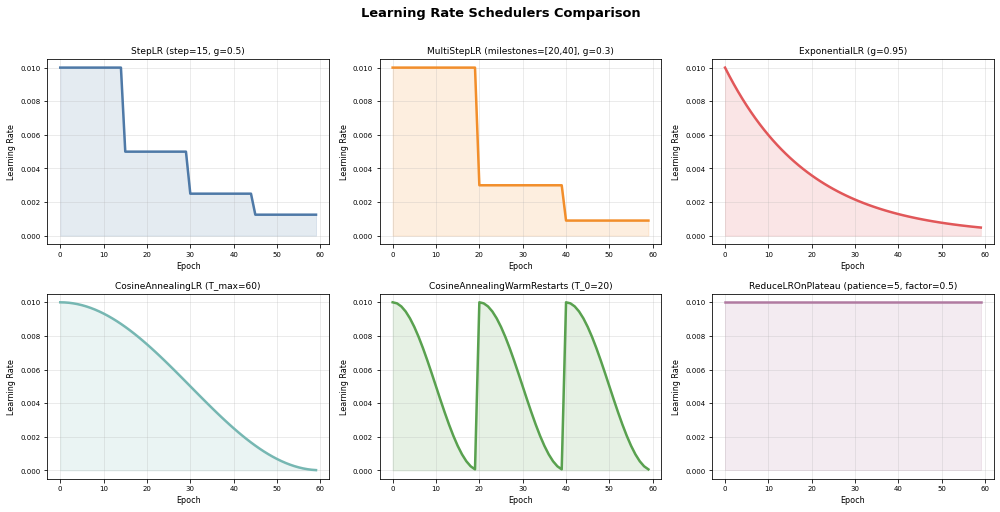

In [18]:
import torch
import matplotlib.pyplot as plt

EPOCHS = 60
LR     = 1e-2

def get_lrs(scheduler_fn):
    model = torch.nn.Linear(10, 1)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    sched = scheduler_fn(opt)
    lrs   = []
    for epoch in range(EPOCHS):
        fake_loss = 1.0 / (epoch + 1)
        lrs.append(opt.param_groups[0]["lr"])
        if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
            sched.step(fake_loss)
        else:
            sched.step()
    return lrs

schedulers = {
    "StepLR (step=15, g=0.5)":
        lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5),
    "MultiStepLR (milestones=[20,40], g=0.3)":
        lambda opt: torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20,40], gamma=0.3),
    "ExponentialLR (g=0.95)":
        lambda opt: torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.95),
    "CosineAnnealingLR (T_max=60)":
        lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5),
    "CosineAnnealingWarmRestarts (T_0=20)":
        lambda opt: torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20),
    "ReduceLROnPlateau (patience=5, factor=0.5)":
        lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=5, factor=0.5),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
colors = ["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f","#b07aa1"]

for ax, (name, sched_fn), color in zip(axes, schedulers.items(), colors):
    lrs = get_lrs(sched_fn)
    ax.plot(range(EPOCHS), lrs, linewidth=2.5, color=color)
    ax.fill_between(range(EPOCHS), lrs, alpha=0.15, color=color)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylabel("Learning Rate", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Rate Schedulers Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


## 16. Train / Validation Split

Never tune hyperparameters on the **test** set.  Use a held-out **validation**
set during training to:
- Monitor generalisation (detect overfitting early).
- Guide early stopping and LR scheduling.
- Select the best checkpoint to evaluate on the test set.

`torch.utils.data.random_split` gives a quick random split.


Total samples  : 60,000
Train samples  : 48,000
Val   samples  : 12,000


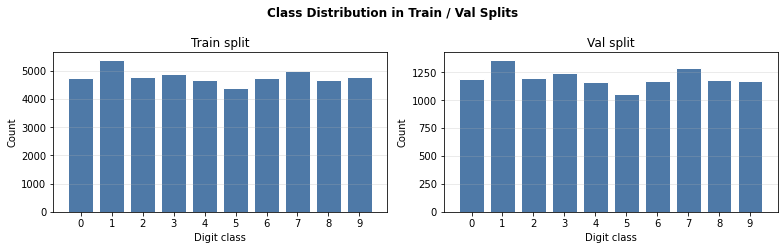

In [19]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

mnist_full = datasets.MNIST(root="data", train=True, download=True,
                            transform=transforms.ToTensor())

# 80/20 split
n_train = int(0.8 * len(mnist_full))
n_val   = len(mnist_full) - n_train
train_ds, val_ds = random_split(mnist_full, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

print(f"Total samples  : {len(mnist_full):,}")
print(f"Train samples  : {len(train_ds):,}")
print(f"Val   samples  : {len(val_ds):,}")

# ── Verify class balance is preserved ────────────────────────────────────────
from collections import Counter
train_labels = [mnist_full[i][1] for i in train_ds.indices]
val_labels   = [mnist_full[i][1] for i in val_ds.indices]
train_counts = [Counter(train_labels)[c] for c in range(10)]
val_counts   = [Counter(val_labels)[c]   for c in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, counts, title in zip(axes,
        [train_counts, val_counts], ["Train split", "Val split"]):
    ax.bar(range(10), counts, color="#4e79a7", edgecolor="white")
    ax.set_xlabel("Digit class"); ax.set_ylabel("Count")
    ax.set_title(title); ax.set_xticks(range(10))
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Class Distribution in Train / Val Splits", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 17. Full Training Loop

We now put everything together: data loading, model, loss, optimiser, and
evaluation — trained with four different weight initialisations to compare
convergence behaviour.

**Exercise**
- Which initialisation converges fastest?
- Which achieves the best test accuracy?


In [20]:
import torch, torch.nn as nn
import torch.nn.init as init
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Data ─────────────────────────────────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,), (0.3081,))])
mnist_full = datasets.MNIST(root="data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="data", train=False, download=True, transform=transform)

n_val  = 10_000
n_train = len(mnist_full) - n_val
train_ds, val_ds = random_split(mnist_full, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)
test_loader  = DataLoader(mnist_test, batch_size=256, shuffle=False, num_workers=2)

# ── Model & inits ─────────────────────────────────────────────────────────────
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10))
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

def init_xavier(m):
    if isinstance(m, nn.Linear): init.xavier_normal_(m.weight); init.zeros_(m.bias)
def init_uniform(m):
    if isinstance(m, nn.Linear): init.uniform_(m.weight, -0.1, 0.1); init.zeros_(m.bias)
def init_kaiming(m):
    if isinstance(m, nn.Linear): init.kaiming_normal_(m.weight, nonlinearity="relu"); init.zeros_(m.bias)
def init_orthogonal(m):
    if isinstance(m, nn.Linear): init.orthogonal_(m.weight); init.zeros_(m.bias)

weight_inits = {
    "Uniform":    init_uniform,
    "Xavier":     init_xavier,
    "Kaiming":    init_kaiming,
    "Orthogonal": init_orthogonal,
}
EPOCHS = 5

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss   = criterion(output, target)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(target)
            correct    += (output.argmax(1) == target).sum().item()
            total      += len(target)
    return total_loss / total, correct / total * 100

results = {}
criterion = nn.CrossEntropyLoss()

for name, fn in weight_inits.items():
    model = SimpleNet().to(device)
    model.apply(fn)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in tqdm(range(EPOCHS), desc=name):
        tl, _ = run_epoch(model, train_loader, criterion, optimizer)
        vl, va = run_epoch(model, val_loader, criterion)
        scheduler.step()
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)

    _, test_acc = run_epoch(model, test_loader, criterion)
    results[name] = {**history, "test_acc": test_acc}
    print(f"{name:12s}  test_acc={test_acc:.2f}%")


Uniform: 100%|██████████| 5/5 [00:15<00:00,  3.06s/it]


Uniform       test_acc=97.94%


Xavier: 100%|██████████| 5/5 [00:15<00:00,  3.03s/it]


Xavier        test_acc=98.13%


Kaiming: 100%|██████████| 5/5 [00:15<00:00,  3.02s/it]


Kaiming       test_acc=97.97%


Orthogonal: 100%|██████████| 5/5 [00:15<00:00,  3.06s/it]


Orthogonal    test_acc=97.95%


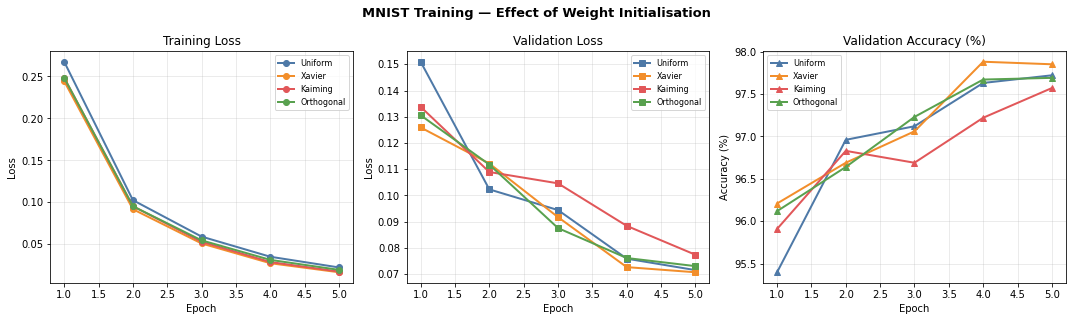

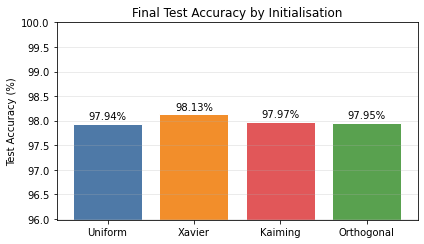

In [21]:
import matplotlib.pyplot as plt

colors = ["#4e79a7","#f28e2b","#e15759","#59a14f"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for (name, res), color in zip(results.items(), colors):
    epochs = range(1, len(res["train_loss"]) + 1)
    axes[0].plot(epochs, res["train_loss"], "o-", label=name, color=color, linewidth=2)
    axes[1].plot(epochs, res["val_loss"],   "s-", label=name, color=color, linewidth=2)
    axes[2].plot(epochs, res["val_acc"],    "^-", label=name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
        ["Training Loss", "Validation Loss", "Validation Accuracy (%)"],
        ["Loss", "Loss", "Accuracy (%)"]):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("MNIST Training — Effect of Weight Initialisation",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Final test accuracy bar chart ─────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(6, 3.5))
names = list(results.keys())
accs  = [results[n]["test_acc"] for n in names]
bars  = ax.bar(names, accs, color=colors, edgecolor="white")
ax.set_ylim(min(accs)*0.98, 100)
ax.set_ylabel("Test Accuracy (%)"); ax.set_title("Final Test Accuracy by Initialisation")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{acc:.2f}%", ha="center", va="bottom", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 18. Gradient Clipping

**Exploding gradients** can occur in deep networks or RNNs: gradients grow
exponentially through many layers, causing the loss to diverge.

Gradient clipping caps the **L2 norm** of the gradient vector before the
optimiser step:

```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

A good default `max_norm` is between 0.5 and 5.0 depending on the architecture.


Gradient norm before clipping : 1.5085
Gradient norm after  clipping : 1.0000


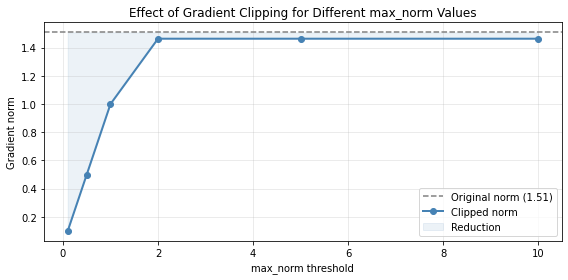

In [22]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Simulate a model where gradients are naturally large
model  = nn.Sequential(nn.Linear(10, 64), nn.Tanh(),
                        nn.Linear(64, 64), nn.Tanh(),
                        nn.Linear(64, 1))
opt    = torch.optim.SGD(model.parameters(), lr=1e-2)
x      = torch.randn(32, 10) * 5    # large inputs → large gradients
target = torch.randn(32, 1)

opt.zero_grad()
loss = nn.MSELoss()(model(x), target)
loss.backward()

def total_norm(params):
    return sum(p.grad.norm()**2 for p in params if p.grad is not None).sqrt().item()

norm_before = total_norm(model.parameters())
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
norm_after  = total_norm(model.parameters())
opt.step()

print(f"Gradient norm before clipping : {norm_before:.4f}")
print(f"Gradient norm after  clipping : {norm_after:.4f}")

# ── Visualise clipping across several max_norm thresholds ────────────────────
thresholds = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
clipped_norms = []

for thr in thresholds:
    opt.zero_grad()
    nn.MSELoss()(model(x), target).backward()
    n_before = total_norm(model.parameters())
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=thr)
    clipped_norms.append(total_norm(model.parameters()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(norm_before, color="grey", linestyle="--", linewidth=1.5,
           label=f"Original norm ({norm_before:.2f})")
ax.plot(thresholds, clipped_norms, "o-", color="steelblue", linewidth=2,
        label="Clipped norm")
ax.fill_between(thresholds, clipped_norms, norm_before,
                alpha=0.1, color="steelblue", label="Reduction")
ax.set_xlabel("max_norm threshold"); ax.set_ylabel("Gradient norm")
ax.set_title("Effect of Gradient Clipping for Different max_norm Values")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 19. Model Saving & Loading

Always save the **`state_dict`** rather than the whole model object — it is
portable across Python versions and doesn't depend on the module import path.

A full checkpoint should include:
- `model_state_dict` — learned weights
- `optimizer_state_dict` — optimiser momentum / adaptive terms
- `epoch` — where to resume
- `loss` / `val_acc` — best metric for model selection


Checkpoint saved  →  checkpoint.pt
Resumed from epoch 10  |  val_loss=0.0812  val_acc=97.63%
Outputs match after reload: True


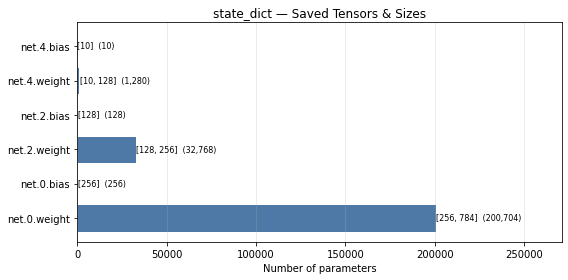

In [23]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784,256), nn.ReLU(),
                                 nn.Linear(256,128), nn.ReLU(),
                                 nn.Linear(128,10))
    def forward(self, x): return self.net(x.view(x.size(0), -1))

model     = SimpleNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ── Save checkpoint ───────────────────────────────────────────────────────────
checkpoint = {
    "epoch"               : 10,
    "model_state_dict"    : model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "val_loss"            : 0.0812,
    "val_acc"             : 97.63,
}
torch.save(checkpoint, "checkpoint.pt")
print("Checkpoint saved  →  checkpoint.pt")

# ── Load and resume ───────────────────────────────────────────────────────────
ckpt       = torch.load("checkpoint.pt", map_location="cpu")
model2     = SimpleNet()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
model2.load_state_dict(ckpt["model_state_dict"])
optimizer2.load_state_dict(ckpt["optimizer_state_dict"])

print(f"Resumed from epoch {ckpt['epoch']}  |"
      f"  val_loss={ckpt['val_loss']}  val_acc={ckpt['val_acc']}%")

# ── Sanity check: outputs must be identical ───────────────────────────────────
model.eval(); model2.eval()
x = torch.randn(4, 784)
with torch.no_grad():
    match = torch.allclose(model(x), model2(x))
print(f"Outputs match after reload: {match}")

# ── Show what's in state_dict ─────────────────────────────────────────────────
keys   = list(model.state_dict().keys())
shapes = [list(model.state_dict()[k].shape) for k in keys]
nparams= [model.state_dict()[k].numel()    for k in keys]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(keys, nparams, color="#4e79a7", edgecolor="white")
ax.set_xlabel("Number of parameters")
ax.set_title("state_dict — Saved Tensors & Sizes")
for bar, n, sh in zip(bars, nparams, shapes):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{sh}  ({n:,})", va="center", fontsize=8)
ax.set_xlim(0, max(nparams) * 1.35)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()
